# Funciones de activación en redes neuronales

Las funciones de activación permiten que una red neuronal aprenda relaciones **no lineales**. En este notebook se grafican y comparan las funciones más utilizadas: escalón, lineal, sigmoide, tangente hiperbólica, ReLU, Leaky ReLU, ELU, Softplus y Softmax.

## 1. Librerías y dominio

Usaremos valores de $x$ entre $-10$ y $10$ para observar el comportamiento de cada función.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
x = np.linspace(-10, 10, 1000)

## 2. Definición de las funciones

- **Escalón:** $f(x)=0$ si $x<0$ y $f(x)=1$ si $x\geq0$
- **Lineal:** $f(x)=x$
- **Sigmoide:** $f(x)=\frac{1}{1+e^{-x}}$
- **Tanh:** $f(x)=\tanh(x)$
- **ReLU:** $f(x)=\max(0,x)$
- **Leaky ReLU:** $f(x)=x$ si $x>0$ y $f(x)=\alpha x$ en otro caso
- **ELU:** $f(x)=x$ si $x>0$ y $f(x)=\alpha(e^x-1)$ en otro caso
- **Softplus:** $f(x)=\ln(1+e^x)$

In [2]:
def escalon(x):
    return np.where(x >= 0, 1.0, 0.0)

def lineal(x):
    return x

def sigmoide(x):
    # El recorte evita desbordamientos numéricos para valores extremos.
    x_seguro = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x_seguro))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0.0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * np.expm1(x))

def softplus(x):
    # logaddexp es una forma numéricamente estable de log(1 + exp(x)).
    return np.logaddexp(0, x)

## 3. Gráficas comparativas

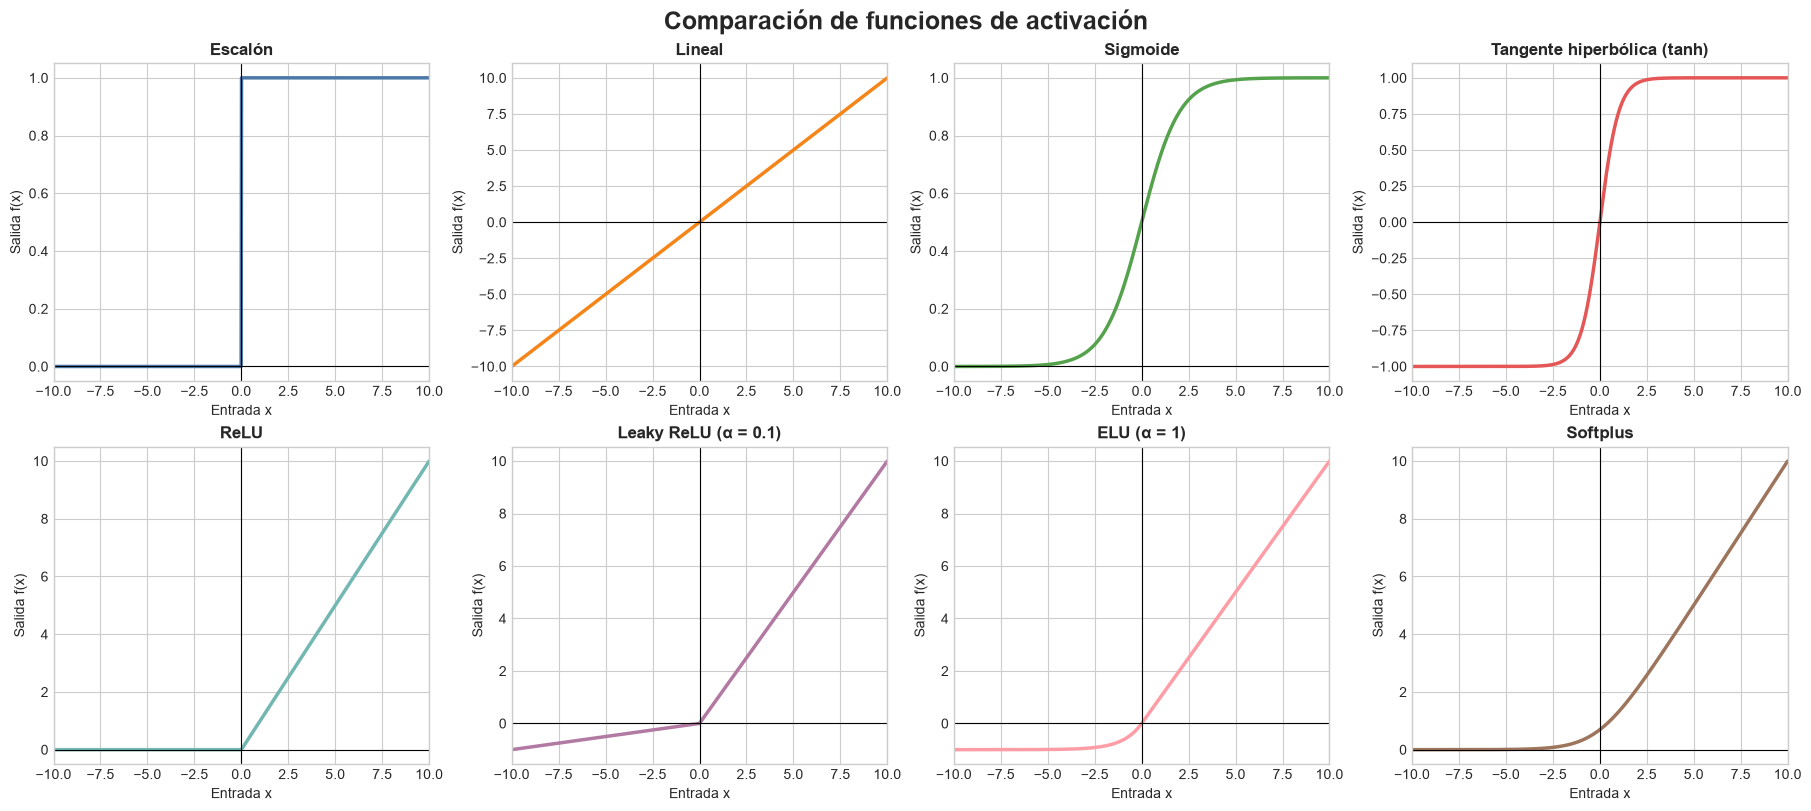

In [ ]:
funciones = [
    ('Escalón', escalon, '#4C78A8'),
    ('Lineal', lineal, '#F58518'),
    ('Sigmoide', sigmoide, '#54A24B'),
    ('Tangente hiperbólica (tanh)', tanh, '#E45756'),
    ('ReLU', relu, '#72B7B2'),
    ('Leaky ReLU (α = 0.1)', leaky_relu, '#B279A2'),
    ('ELU (α = 1)', elu, '#FF9DA6'),
    ('Softplus', softplus, '#9D755D'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)

for ax, (nombre, funcion, color) in zip(axes.flat, funciones):
    ax.plot(x, funcion(x), color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Entrada x')
    ax.set_ylabel('Salida f(x)')
    ax.set_xlim(-10, 10)

fig.suptitle('Comparación de funciones de activación', fontsize=18, fontweight='bold')
plt.show()

## 4. Softmax

Softmax no se aplica a un solo número de manera aislada, sino a un **vector de puntuaciones** o *logits*. Convierte esas puntuaciones en probabilidades cuya suma es 1:

$$\operatorname{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}$$

Se utiliza normalmente en la capa de salida de un problema de clasificación multiclase.

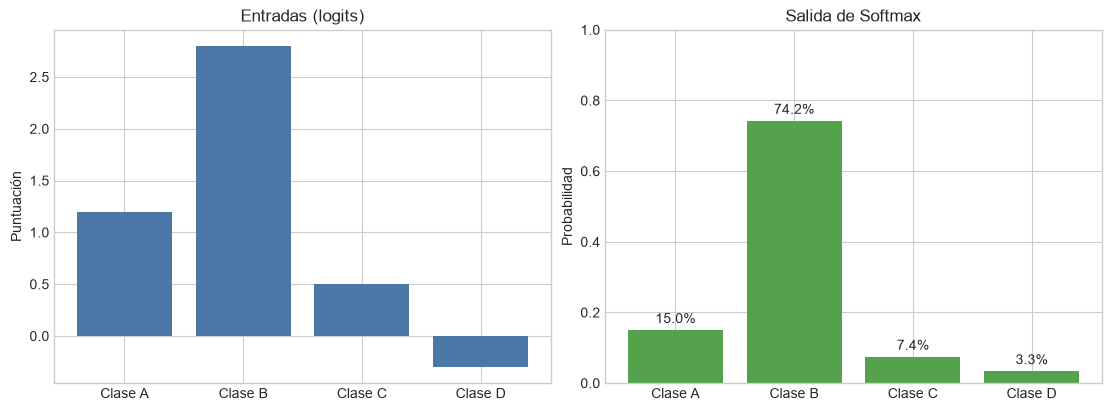

Suma de probabilidades: 1.00


In [4]:
def softmax(z):
    z = np.asarray(z, dtype=float)
    exp_z = np.exp(z - np.max(z))  # Estabilidad numérica
    return exp_z / exp_z.sum()

clases = ['Clase A', 'Clase B', 'Clase C', 'Clase D']
logits = np.array([1.2, 2.8, 0.5, -0.3])
probabilidades = softmax(logits)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].bar(clases, logits, color='#4C78A8')
axes[0].set_title('Entradas (logits)')
axes[0].set_ylabel('Puntuación')

barras = axes[1].bar(clases, probabilidades, color='#54A24B')
axes[1].set_title('Salida de Softmax')
axes[1].set_ylabel('Probabilidad')
axes[1].set_ylim(0, 1)
for barra, probabilidad in zip(barras, probabilidades):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.02,
                 f'{probabilidad:.1%}', ha='center')

plt.show()
print(f'Suma de probabilidades: {probabilidades.sum():.2f}')

## 5. Derivadas y aprendizaje

Durante el entrenamiento, la red utiliza derivadas para actualizar sus pesos. Una derivada casi igual a cero puede hacer que el aprendizaje sea muy lento (problema del **gradiente desvanecido**).

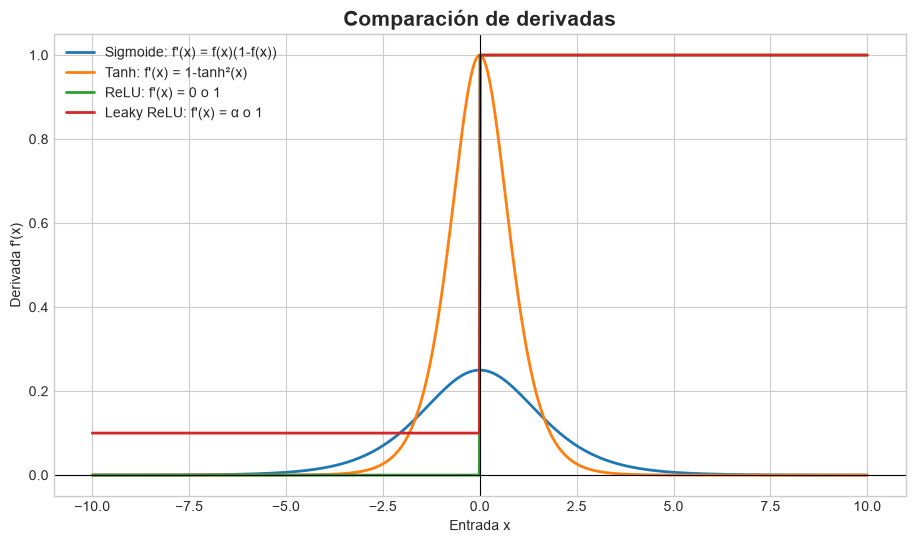

In [ ]:
s = sigmoide(x)
derivadas = {
    "Sigmoide: f'(x) = f(x)(1-f(x))": s * (1 - s),
    "Tanh: f'(x) = 1-tanh²(x)": 1 - np.tanh(x)**2,
    "ReLU: f'(x) = 0 o 1": np.where(x > 0, 1.0, 0.0),
    "Leaky ReLU: f'(x) = α o 1": np.where(x > 0, 1.0, 0.1),
    
}

plt.figure(figsize=(11, 6))
for etiqueta, valores in derivadas.items():
    plt.plot(x, valores, linewidth=2, label=etiqueta)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Comparación de derivadas', fontsize=15, fontweight='bold')
plt.xlabel('Entrada x')
plt.ylabel("Derivada f'(x)")
plt.legend()
plt.show()

## 6. ¿Cuándo se usa cada función?

| Función | Rango de salida | Uso típico | Observación |
|---|---:|---|---|
| Escalón | $\{0,1\}$ | Perceptrón clásico | No es derivable en 0 y su gradiente es 0 fuera de ese punto |
| Lineal | $(-\infty,\infty)$ | Salida de regresión | No agrega no linealidad |
| Sigmoide | $(0,1)$ | Salida de clasificación binaria | Puede sufrir gradiente desvanecido |
| Tanh | $(-1,1)$ | Estados de algunas redes recurrentes | Centrada en cero, pero también puede saturarse |
| ReLU | $[0,\infty)$ | Capas ocultas | Rápida y muy común; puede producir neuronas muertas |
| Leaky ReLU | $(-\infty,\infty)$ | Capas ocultas | Conserva un gradiente pequeño para entradas negativas |
| ELU | $(-\alpha,\infty)$ | Capas ocultas | Suave para valores negativos, pero más costosa que ReLU |
| Softplus | $(0,\infty)$ | Alternativa suave a ReLU | Siempre es derivable |
| Softmax | $(0,1)$ y suma 1 | Salida multiclase | Produce una distribución de probabilidades |

## Conclusiones

- Para **capas ocultas**, ReLU suele ser el punto de partida; Leaky ReLU o ELU ayudan cuando aparecen neuronas muertas.
- Para la **salida binaria**, se usa sigmoide.
- Para la **salida multiclase**, se usa Softmax.
- Para una **regresión**, normalmente se usa una salida lineal.
- La elección depende de la arquitectura, el problema y el comportamiento del gradiente durante el entrenamiento.